Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.8627749006308211
Classification Report of Optimized Random Forest:
              precision    recall  f1-score   support

         0.0       0.24      0.21      0.22       951
         1.0       0.89      0.91      0.90      6987

    accuracy                           0.83      7938
   macro avg       0.57      0.56      0.56      7938
weighted avg       0.82      0.83      0.82      7938



C:\Users\bog23\AppData\Local\Temp\ipykernel_11136\499564335.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


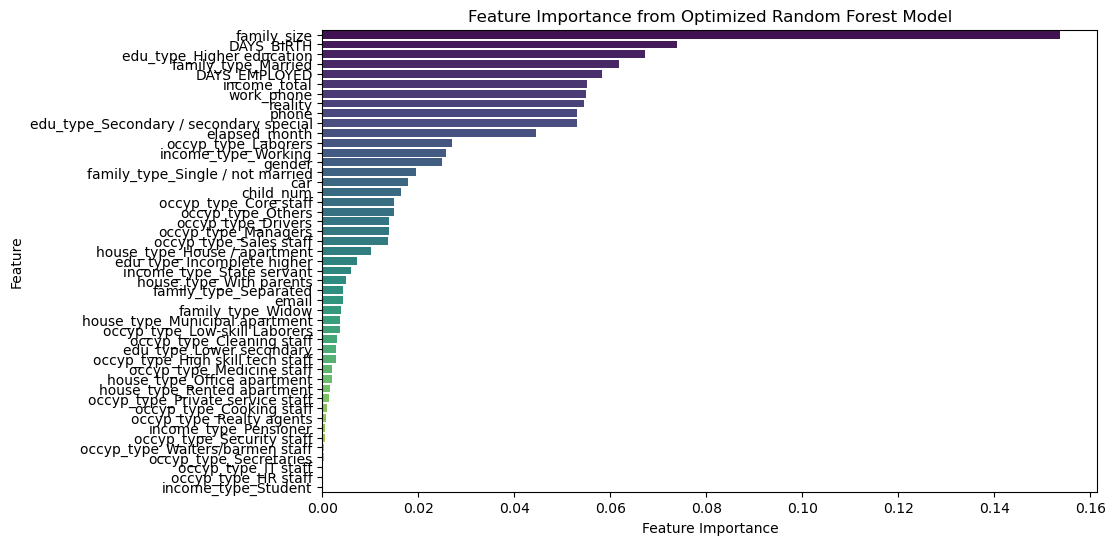

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("data/processed_credit_data_5.csv")

# 피처와 타겟 변수 분리
X = df.drop(columns=['delinquency', 'index'])
y = df['delinquency']

# 클래스 레이블 재매핑: 1, 2 → 1
y = y.replace({1.0: 1, 2.0: 1})

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# GridSearch 하이퍼파라미터 최적화 (트리 개수 제한)
param_grid = {
    'n_estimators': [50, 100, 200],  
    'max_depth': [5, 10],  # 깊이 제한
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 5],  
    'max_features': ['sqrt', 'log2', 0.8],  
    'bootstrap': [True, False],  # 부트스트랩 샘플링 여부
    'class_weight': ['balanced']  
}

# GridSearchCV 실행
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=param_grid,
    scoring='f1',
    cv=3,         # 교차검증 3-폴드 유지 (LGBM과 동일하게)
    verbose=2,    # 출력 세부 조절
    n_jobs=-1     # 병렬 처리 최적화
)

# 모델 학습
grid_search.fit(X_train_smote, y_train_smote)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# 최적 모델로 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 모델 평가
print("Classification Report of Optimized Random Forest:")
print(classification_report(y_test, y_pred))

# 변수 중요도 시각화
feature_importances = best_model.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Optimized Random Forest Model')
plt.show()